Test the perturbed slab model created.

In [14]:
import numpy as np
from slab_bfield import SlabBfield
from pyoculus.maps import ToroidalBfieldSection
from pyoculus.solvers import PoincarePlot
import matplotlib.pyplot as plt

#### Create the magnetic field:

In [39]:
field = SlabBfield(
    m=2,
    n=0,
    delta=0.01,
    iota_prime=1.0,
    x0=0.5,
)

coords = np.array([0.4, 0.2, 0.3])

print("B:")
print(field.B(coords))

print("\nB and dBdX:")
B, dBdX = field.dBdX(coords)

print(B)
print(dBdX)

print("The island will be situated at x_s =", field.x0 + field.n / (field.iota_prime * field.m))

B:
[ 0.00186921 -0.09815788  1.        ]

B and dBdX:
[ 0.00186921 -0.09815788  1.        ]
[[ 0.00155767  0.00884219  0.        ]
 [ 0.98157878 -0.00155767  0.        ]
 [ 0.          0.          0.        ]]
The island will be situated at x_s = 0.5


In [40]:
Bx = field.m*field.delta*coords[0]*(1-coords[0])*np.sin(field.m*coords[1] - field.n*coords[2])
By = field.iota_prime*(coords[0]-field.x0)+field.delta*coords[1]*np.cos(field.m*coords[1] - field.n*coords[2])
print(Bx, By)

0.0018692080430815223 -0.0981578780119942


#### Create the map:

In [41]:
section = ToroidalBfieldSection(field)

In [42]:
x0 = np.array([0.4, 0.2])
x1 = section.f(1, x0)
x2 = section.f(1, x1)

print("Initial point:")
print(x0)

print("After one map iteration:")
print(x1)

print("After two map iterations:")
print(x2)

Initial point:
[0.4 0.2]
After one map iteration:
[0.39410824 5.86606102]
After two map iterations:
[0.36719957 5.11581684]


#### Create Poincaré plot:

In [43]:
# Initial conditions from x = 0.05 to x = 0.95, all at y = 0
pplot = PoincarePlot.with_linspace(
    section,
    np.array([0.05, 0.0]),
    np.array([0.95, 0.0]),
    npts=50
)

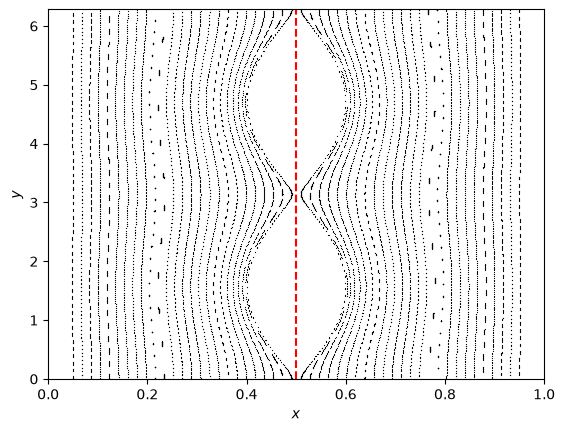

In [44]:

# Follow each initial condition for 200 crossings
pplot.compute(npts=250)

# Plot directly in (x,y) coordinates
fig, ax = pplot.plot(plottype=None) # plottypeNone to directly plot in the coordinates of the map

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_xlim(0, 1)
ax.set_ylim(0, 2*np.pi)

xs = field.x0 + field.n / (field.iota_prime * field.m)

ax.axvline(
    xs,
    linestyle="--",
    label=rf"$x_s={xs:.3f}$",
    color="r"
)

plt.show()